### Ejercicio 1: Análisis Descriptivo de Datos con Pandas y Matplotlib
***
Enunciado: trabajarás con un conjunto de datos simple sobre las ventas de diferentes productos. Tu tarea es cargar estos datos en un DataFrame de Pandas y realizar un análisis exploratorio básico utilizando Matplotlib.

Desarrollo Sugerido:
1. Crea un diccionario en Python que contenga datos de ventas. Por
ejemplo:
datos = {
'producto': ['Laptop', 'Teclado', 'Monitor', 'Mouse', 'Auriculares'],
'ventas': [150, 200, 120, 350, 180]
}
1. Importa las librerías pandas y matplotlib.pyplot y crea un DataFrame de
Pandas a partir de tu diccionario.
2. Utiliza Matplotlib para crear un gráfico de barras que muestre las ventas
de cada producto.
3. Asegúrate de personalizar el gráfico con un título, etiquetas para los ejes
(xlabel y ylabel), y colores a tu elección.
4. Usa plt.show() para visualizar el gráfico.

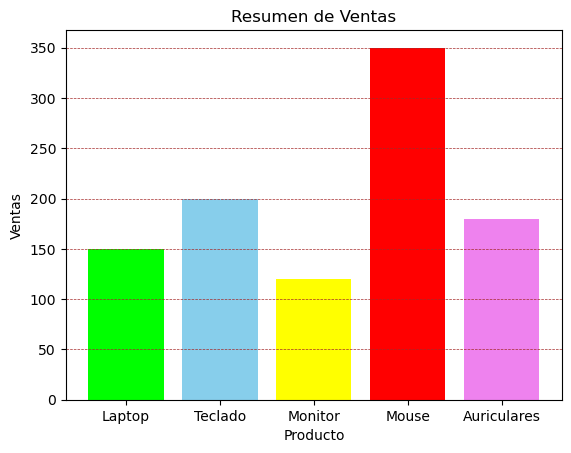

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

datos = { 'producto': ['Laptop', 'Teclado', 'Monitor', 'Mouse', 'Auriculares'], 'ventas': [150, 200, 120, 350, 180] }

df = pd.DataFrame(datos)

plt.bar(df["producto"],df["ventas"], color = ["lime", "skyblue", "yellow", "red", "violet"])
plt.title("Resumen de Ventas")
plt.xlabel("Producto")
plt.ylabel("Ventas")
plt.grid(axis = 'y', color = "brown", linestyle = '--', linewidth = 0.5)
plt.show()


### Ejercicio 2: Visualización de distribuciones con gráficos de caja y violín
***
Enunciado: simula datos de salarios para dos departamentos diferentes de una empresa. Tu objetivo es comparar la distribución de salarios entre estos departamentos utilizando un diagrama de caja y bigotes (boxplot ) y un gráfico de violín.

Desarrollo Sugerido:
1. Importa numpy y matplotlib.pyplot.
2. Genera datos simulados para salarios_marketing y salarios_tecnologia usando np.random.normal().
3. Utiliza plt.subplots() para crear una figura con dos subgráficos, uno al lado del otro.
4. En el primer subgráfico, usa ax1.boxplot() para mostrar la distribución de salarios.
5. En el segundo subgráfico, usa ax2.violinplot() para mostrar la misma distribución de salarios.
6. Añade títulos descriptivos a cada subgráfico y a la figura completa (suptitle).

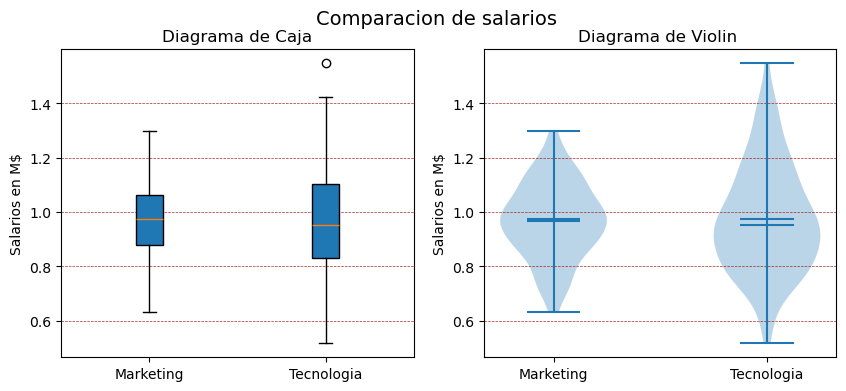

In [2]:
import matplotlib.pyplot as plt
import numpy as np

salarios_marketing = np.round(np.random.normal(loc = 1e6, scale = 150e3, size = 100),0)
salarios_tecnologia = np.round(np.random.normal(loc = 1e6, scale = 200e3, size = 100),0)
salarios = [salarios_marketing/1e6, salarios_tecnologia/1e6]



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 4])
formato = { "ticks": (1,2), "etiquetas": ("Marketing", "Tecnologia")}

fig.suptitle("Comparacion de salarios", fontsize=14)

ax1.grid(axis = 'y', color = "brown", linestyle = '--', linewidth = 0.5)
ax1.boxplot(salarios, patch_artist=True) 
ax1.set_title("Diagrama de Caja")
ax1.set_ylabel("Salarios en M$")
ax1.set_xticks(formato["ticks"])
ax1.set_xticklabels(formato["etiquetas"])

ax2.grid(axis = 'y', color = "brown", linestyle = '--', linewidth = 0.5)
ax2.violinplot(salarios, showmeans=True, showmedians=True)
ax2.set_title("Diagrama de Violin ")
ax2.set_ylabel("Salarios en M$")
ax2.set_xticks(formato["ticks"])
ax2.set_xticklabels(formato["etiquetas"])

plt.show()



### Ejercicio 3: Integración de la API de IA en una función de resumen
***
Enunciado: desarrolla un programa que tenga una función llamada resumir_texto(texto_largo) que utilice la API de Gemini para generar un
resumen. La función debe manejar los errores de conexión o de la API de forma controlada y debe estar protegida para que la clave de API no quede expuesta en el código.

Desarrollo Sugerido:
1. Asegúrate de que la API key de Gemini esté guardada en una variable de entorno.
2. Define una función resumir_texto(texto_largo) que tome un texto como parámetro.
3. Dentro de la función, usa un bloque try...except para configurar la API y llamar al modelo gemini-pro.
4. Formula un prompt claro para pedirle a la IA que resuma el texto.
5. Retorna el texto resumido si la operación es exitosa o un mensaje de error en caso de falla.
6. Llama a la función con un texto largo de tu elección e imprime el resultado.

In [3]:
import os
from google import genai
from google.genai import errors

def check_key():
    KEY = "GEMINI_API_KEY"

    api_key = os.getenv(KEY)

    if api_key is None:
        return f"{KEY} no encontrada!\n"
    else:
        return f"{KEY} encontrada.\n"


def resumir_texto(texto):
    try:
        client = genai.Client()
        consulta = "Resume el siguiente texto:" + texto
        response = client.models.generate_content( model="gemini-3-flash-preview", contents=consulta)
        return response.text
        
    except errors.ServerError as e:
        print(f"Server error: {e.message}. Please try again later.")

def main():
    texto = """
    La batalla de San Juan y Chorrillos fue una acción militar ocurrida el 13 de enero de 1881, en el marco de la guerra del Pacífico. 
    En ella se enfrentaron el Ejército de Chile y el Ejército del Perú.Esta batalla se desarrolló consecutivamente en Villa, 
    las pampas de San Juan y Santa Teresa, el cerro Marcavilca, el morro Solar y el pueblo de Chorrillos. Después de ocho horas de 
    combates en diversos frentes, el ejército chileno resultó victorioso. Luego de la batalla, hubo incendios y saqueos en Chorrillos 
    y Barranco. También se acordó una tregua, el llamado Armisticio de San Juan, y se efectuaron negociaciones mientras ambos ejércitos 
    hacían preparativos para otra posible batalla, que finalmente se produjo por un confuso incidente que derivó en la batalla de 
    Miraflores, después de la cual las tropas chilenas entraron a Lima y pusieron fin a la tercera campaña terrestre de la guerra. 
    Fue la mayor batalla librada durante la guerra y una de las más grandes de América del Sur, en lo que concierne al número de 
    combatientes. Según algunos historiadores debió finalizar la Campaña de Lima con este enfrentamiento, ya que los remanentes 
    peruanos en la línea defensiva de Miraflores no estaban en situación de contener el avance chileno.
"""

    print(check_key())
    print(resumir_texto(texto))

if __name__ == "__main__":
    main()



GEMINI_API_KEY encontrada.

Aquí tienes un resumen del texto:

La **Batalla de San Juan y Chorrillos**, ocurrida el 13 de enero de 1881 durante la Guerra del Pacífico, fue uno de los enfrentamientos más grandes de Sudamérica por su número de combatientes. Tras ocho horas de combate en diversos frentes, el **ejército chileno derrotó al peruano**, lo que derivó en el saqueo de Chorrillos y Barranco. Aunque se pactó una tregua temporal, la falta de un acuerdo definitivo llevó a la batalla de Miraflores y la posterior ocupación de Lima. Historiadores señalan que esta victoria chilena fue decisiva, ya que las defensas peruanas restantes no tenían capacidad para detener el avance hacia la capital.


### Ejercicio 4: Generación de Listas con la API de IA en un Bucle
***
Enunciado: crea un programa interactivo donde el usuario pueda solicitar a la API de Gemini que genere una lista de elementos para una categoría específica. El programa debe continuar pidiendo categorías hasta que el usuario ingrese la
palabra "salir".

Desarrollo Sugerido:
1. Asegúrate de tener la configuración de la API de Gemini en tu programa.
2. Inicia un bucle while True para una interacción continua.
3. Dentro del bucle, pide al usuario que ingrese una categoría (input()).
4. Si la entrada del usuario es "salir", usa break para terminar el bucle.
5. Crea un prompt que le pida a la IA que genere una lista de 5 elementos para la categoría ingresada.
6. Usa un bloque try...except para llamar a la API y procesar la respuesta.
7. Imprime la lista generada en un formato claro para el usuario.

In [10]:
import os
from google import genai
from google.genai import errors

def check_key():
    KEY = "GEMINI_API_KEY"

    api_key = os.getenv(KEY)

    if api_key is None:
        return f"{KEY} no encontrada!\n"
    else:
        return f"{KEY} encontrada.\n"

def main():
    print(check_key())
    
    while True:
        categoria = input("\nIngrese categoria: (salir para salir)")
        if categoria.lower() == "salir":
            break
            
        client = genai.Client()
        prompt = f"genera una lista de 5 elementos de la siguiente categoria: {categoria} sin descripcion"
        
        try:
            response = client.models.generate_content( model="gemini-3-flash-preview", contents=prompt)
            print(response.text)
        
        except Exception as e:
            print(f"No se pudo generar la lista: {e}")

if __name__ == "__main__":
    main()

GEMINI_API_KEY encontrada.




Ingrese categoria: (salir para salir) ideas de almuerzo con poca plata


1. Arroz con huevo frito
2. Lentejas con arroz
3. Fideos con aceite y queso rallado
4. Tortilla de papas
5. Polenta con salsa de tomate



Ingrese categoria: (salir para salir) ideas de almuerzo con muy poco dinero y que no tengas papas ni arroz


1. Lentejas guisadas con verduras
2. Pasta con ajo y aceite de oliva
3. Tortilla de espinacas y huevo
4. Garbanzos salteados con cebolla
5. Polenta con queso y tomate



Ingrese categoria: (salir para salir) salir


### Ejercicio 5: Afirmaciones (assert) en un Analizador de Datos
***
Enunciado: crea una clase AnalizadorDeDatos que tome una lista de números. En su constructor, utiliza assert para garantizar que la lista no esté vacía y que todos sus elementos sean numéricos. Luego, implementa un método para graficar la distribución de los datos usando un histograma de Matplotlib.

Desarrollo Sugerido:
1. Define la clase AnalizadorDeDatos con un constructor que reciba datos.
2. En el constructor, usa assert para verificar si la lista de datos no está vacía.
3. Usa otro assert dentro de una comprensión de lista para verificar que todos los elementos sean int o float.
4. Implementa un método graficar_histograma(self) que cree y muestre un histograma de los datos.
5. Crea un objeto con datos válidos para verificar su correcto funcionamiento.
6. Usa un bloque try...except para intentar crear un objeto con datos inválidos (ej. una lista vacía o una lista con una cadena de texto) y
captura el AssertionError.

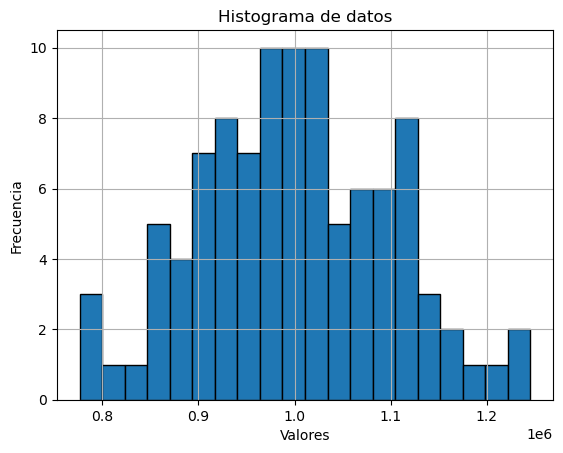

In [41]:
import matplotlib.pyplot as plt
import numpy as np

class AnalizadorDeDatos:
    def __init__(self,datos):
        assert isinstance(datos, list) and len(datos) > 0 , "La lista de datos no puede estar vacia"
        assert all(isinstance(item, (int, float)) for item in datos), "Los datos solo pueden ser numeros"

        self.datos = datos
        
    def graficar_histograma(self):
        plt.hist(self.datos, bins = 20, edgecolor="black")
        plt.title("Histograma de datos")
        plt.xlabel("Valores")
        plt.ylabel("Frecuencia")
        plt.grid()    
        plt.show()
try:
    datos = list(np.random.normal(loc = 1e6, scale = 100e3, size = 100)) # Genero una lista de datos aleatoria
    datos_1 = AnalizadorDeDatos(datos)
    datos_1.graficar_histograma()
    
except AssertionError as error:
    print(f"Error! : {error}")

In [44]:
type(5//3)


int